# 💳 CREDIT RISK INTELLIGENCE: END-TO-END PIPELINE
---
**Author:** Shivam Maurya
 
**Status:** Production Ready  
**Objective:** Maximize net financial benefit by optimizing the credit rejection threshold using advanced Machine Learning.

### 🔬 SYSTEM ARCHITECTURE & STRATEGY
This system employs a **Profit-First** machine learning strategy. Unlike traditional models that optimize for accuracy, we optimize for **Net Portfolio Value**.

**Core Pillars:**
1. **Robust Preprocessing:** SMOTE + RobustScaler for imbalanced and noisy financial data.
2. **Feature Parity:** Exact 125-feature engineering synchronized between training and production.
3. **Threshold Calibration:** Automated search for the 'Sweet Spot' between risk-taking and profit-making.
4. **SHAP Explainability:** Local and global interpretability for regulatory compliance.

In [91]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



import joblib
import json
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, r2_score, log_loss, average_precision_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# Define project structure paths
BASE_DIR = '..' # Root of the project
DATA_DIR = os.path.join(BASE_DIR, 'datasets')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

# Create directories if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Setup Environment
warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn')

print('\n✅ All imports successful!')



✅ All imports successful!


## 1️⃣ DATA INGESTION & EXPLORATION
**Strategy:** Loading raw application data and establishing path hierarchies for models and results. We use a centralized `DATA_DIR` to ensure reproducibility across training and API environments.

In [92]:
# Load Data from datasets folder
print('Loading datasets...')
app_train = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))
app_test = pd.read_csv(os.path.join(DATA_DIR, 'application_test.csv'))

print(f'✅ Train set: {app_train.shape}')
print(f'✅ Test set:  {app_test.shape}')

# Class distribution
print(f'\nClass Distribution:')
print(app_train['TARGET'].value_counts())
print(f'\nImbalance Ratio: {(app_train["TARGET"]==0).sum() / (app_train["TARGET"]==1).sum():.2f}:1')

Loading datasets...
✅ Train set: (307511, 122)
✅ Test set:  (48744, 121)

Class Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Imbalance Ratio: 11.39:1


## 2️⃣ ADVANCED FEATURE ENGINEERING & PREPROCESSING
**Strategy:** 
- **Anomalies:** Capping `DAYS_EMPLOYED` and handling outliers using domain-specific knowledge.
- **Scaling:** Utilizing `RobustScaler` to mitigate the influence of extreme credit values.
- **Engineering:** Creating 125 unique features including `DAYS_EMPLOYED_PERCENT` to capture borrower risk profiles.

In [93]:
# Data Preparation
print('='*70)
print('DATA PREPROCESSING')
print('='*70)

# Handle anomalies
app_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app_test['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
print('✅ DAYS_EMPLOYED anomaly handled')

# Encode categoricals
for col in app_train.select_dtypes('object').columns:
    le = LabelEncoder()
    app_train[col] = le.fit_transform(app_train[col].astype(str))
    app_test[col] = le.transform(app_test[col].astype(str))

app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

train_labels = app_train['TARGET']
app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train['TARGET'] = train_labels

print(f'✅ Categoricals encoded: Train {app_train.shape}, Test {app_test.shape}')

# Feature Engineering - Domain Features
print('\n✅ Domain Features:')
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / (app_train['AMT_INCOME_TOTAL'] + 1)
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / (app_train['AMT_INCOME_TOTAL'] + 1)
app_train['CREDIT_TERM'] = app_train['AMT_ANNUITY'] / (app_train['AMT_CREDIT'] + 1)
app_train['INCOME_PER_PERSON'] = app_train['AMT_INCOME_TOTAL'] / (app_train['CNT_FAM_MEMBERS'].replace(0, 1))

app_test['CREDIT_INCOME_RATIO'] = app_test['AMT_CREDIT'] / (app_test['AMT_INCOME_TOTAL'] + 1)
app_test['ANNUITY_INCOME_RATIO'] = app_test['AMT_ANNUITY'] / (app_test['AMT_INCOME_TOTAL'] + 1)
app_test['CREDIT_TERM'] = app_test['AMT_ANNUITY'] / (app_test['AMT_CREDIT'] + 1)
app_test['INCOME_PER_PERSON'] = app_test['AMT_INCOME_TOTAL'] / (app_test['CNT_FAM_MEMBERS'].replace(0, 1))

print(f'   • CREDIT_INCOME_RATIO')
print(f'   • ANNUITY_INCOME_RATIO')
print(f'   • CREDIT_TERM')
print(f'   • INCOME_PER_PERSON')
print(f'\n✅ Total features now: {app_train.shape[1]}')

# Prepare ML arrays
train_labels = app_train['TARGET']
train_features = app_train.drop(columns=['TARGET'])
test_features = app_test.copy()

imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0, 1))

X_train = imputer.fit_transform(train_features)
X_test = imputer.transform(test_features)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'\n✅ ML Arrays Ready: X_train {X_train.shape}, X_test {X_test.shape}')

DATA PREPROCESSING
✅ DAYS_EMPLOYED anomaly handled
✅ Categoricals encoded: Train (307511, 122), Test (48744, 121)

✅ Domain Features:
   • CREDIT_INCOME_RATIO
   • ANNUITY_INCOME_RATIO
   • CREDIT_TERM
   • INCOME_PER_PERSON

✅ Total features now: 126

✅ ML Arrays Ready: X_train (307511, 125), X_test (48744, 125)


## 📊 EVALUATION HELPERS

In [94]:
def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    """Comprehensive metrics evaluation."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba),
        'PR-AUC': average_precision_score(y_true, y_pred_proba),
        'Log Loss': log_loss(y_true, y_pred_proba),
        'R² Score': r2_score(y_true, y_pred_proba),
    }
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f'\n{"="*65}')
    print(f'  📊 {name} — Performance Metrics')
    print(f'{"="*65}')
    for k, v in metrics.items():
        print(f'  {k:<20} {v:.4f}')
    print(f'{"="*65}')
    
    print(f'\n📈 Classification Report:')
    print(classification_report(y_true, y_pred, 
                               target_names=['Repaid (0)', 'Default (1)']))
    
    print(f'\n🎯 Confusion Matrix:')
    print(f'   TP (Caught): {tp:6d} | FN (Missed): {fn:6d}')
    print(f'   FP (False): {fp:6d} | TN (Correct): {tn:6d}')
    
    return metrics, cm

print('✅ Evaluation helper defined')

✅ Evaluation helper defined


## 3️⃣ FINANCIAL OPTIMIZATION FRAMEWORK
**Strategy:** We move beyond simple accuracy. Our goal is **Loss Minimization**. We calculate the real-world cost of a default versus the opportunity cost of rejecting a good customer to find the 'Dollar-Optimal' threshold.

In [95]:

# ==========================================================================================
# 💰 GLOBAL FINANCIAL CONSTANTS (CALCULATED FROM DATASET)
# ==========================================================================================

# Loss per default: Median credit amount of the population
GLOBAL_LOSS_PER_DEFAULT = int(app_train['AMT_CREDIT'].median())

# Opportunity cost: Potential interest loss if we reject a good applicant
# Estimated as 10% of annual annuity for a typical 'repaid' applicant
repaid_applicants = app_train[app_train['TARGET'] == 0]
GLOBAL_COST_PER_REJECTED_GOOD = int(repaid_applicants['AMT_ANNUITY'].median() * 12 * 0.10)

print(f"📊 Calculated Financial Parameters:")
print(f"   • Loss per Default: ${GLOBAL_LOSS_PER_DEFAULT:,}")
print(f"   • Cost per Good Rejection: ${GLOBAL_COST_PER_REJECTED_GOOD:,}")


📊 Calculated Financial Parameters:
   • Loss per Default: $513,531
   • Cost per Good Rejection: $29,851


In [96]:

# ==========================================================================================
# 📈 FINANCIAL IMPACT CALCULATION HELPER
# ==========================================================================================

def calculate_financial_outcome(y_true, y_proba, threshold):
    """
    Calculates the financial outcome of a model at a specific threshold.
    Uses GLOBAL_LOSS_PER_DEFAULT and GLOBAL_COST_PER_REJECTED_GOOD.
    """
    y_pred = (y_proba >= threshold).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Financials
    # 1. Savings from defaults caught: TP * Loss per Default
    defaults_caught_savings = tp * GLOBAL_LOSS_PER_DEFAULT
    
    # 2. Loss from missed defaults (False Negatives): FN * Loss per Default
    # (Though we usually focus on net benefit)
    
    # 3. Cost from rejected good applicants (False Positives): FP * Cost per Rejection
    rejection_cost = fp * GLOBAL_COST_PER_REJECTED_GOOD
    
    # Net Benefit
    net_benefit = defaults_caught_savings - rejection_cost
    
    # Total Financial Loss (Missed Defaults + Cost of Rejections)
    total_loss = (fn * GLOBAL_LOSS_PER_DEFAULT) + rejection_cost
    
    return {
        'threshold': threshold,
        'defaults_caught': tp,
        'missed_defaults': fn,
        'false_positives': fp,
        'true_negatives': tn,
        'savings_from_defaults': defaults_caught_savings,
        'loss_from_rejections': rejection_cost,
        'net_benefit': net_benefit,
        'total_financial_loss': total_loss
    }

print('✅ Financial impact calculation helper defined')


✅ Financial impact calculation helper defined


## 4️⃣ MULTI-MODEL COMPETITION & TRAINING
**Strategy:** We train three distinct architectures: Random Forest (Balanced), LightGBM (SMOTE), and XGBoost (Cost-Sensitive).

In [97]:
print('\n' + '='*100)
print('  MODEL TRAINING: RANDOM FOREST, LIGHTGBM, XGBOOST')
print('='*100)

# ════════════════════════════════════════════════════════════════════════════════
# MODEL 1: RANDOM FOREST WITH CLASS WEIGHTING
# ════════════════════════════════════════════════════════════════════════════════

print('\n1️⃣ Training Random Forest Classifier...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_final_scaled, train_labels_final)
rf_proba = rf_model.predict_proba(X_train_final_scaled)[:, 1]
print(f'   ✅ Random Forest trained: {rf_model}')
print(f'   ✅ ROC-AUC on training: {roc_auc_score(train_labels_final, rf_proba):.4f}')

# ════════════════════════════════════════════════════════════════════════════════
# MODEL 2: LIGHTGBM WITH SMOTE
# ════════════════════════════════════════════════════════════════════════════════

print('\n2️⃣ Training LightGBM with SMOTE...')

# Apply SMOTE to balance training data
smote_sampler = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train_final_scaled, train_labels_final)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_smote) / (2 * np.sum(y_train_smote)),
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgb_model.fit(X_train_smote, y_train_smote)
lgb_proba = lgb_model.predict_proba(X_train_final_scaled)[:, 1]
print(f'   ✅ LightGBM trained with SMOTE')
print(f'   ✅ ROC-AUC on training: {roc_auc_score(train_labels_final, lgb_proba):.4f}')

# ════════════════════════════════════════════════════════════════════════════════
# MODEL 3: XGBOOST WITH COST-SENSITIVE LEARNING & CROSS-VALIDATION
# ════════════════════════════════════════════════════════════════════════════════

print('\n3️⃣ Training XGBoost with Cost-Sensitive Learning (5-Fold CV)...')

# Calculate scale_pos_weight for cost-sensitive learning
scale_pos_weight = len(train_labels_final) / (2 * np.sum(train_labels_final))
print(f'   • scale_pos_weight = {scale_pos_weight:.2f}x (cost-sensitive)')

# Initialize XGBoost with optimal parameters
xgb_params = {
    'max_depth': 7,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
    'eval_metric': 'aucpr'
}

# 5-Fold stratified cross-validation
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_oof_preds = np.zeros(len(train_labels_final))
xgb_cv_scores = []

for fold_idx, (train_idx, val_idx) in enumerate(cv_folds.split(X_train_final_scaled, train_labels_final)):
    print(f'   • Fold {fold_idx+1}/5', end='')
    
    X_fold_train, X_fold_val = X_train_final_scaled[train_idx], X_train_final_scaled[val_idx]
    y_fold_train, y_fold_val = train_labels_final.iloc[train_idx].values, train_labels_final.iloc[val_idx].values
    
    xgb_fold_model = xgb.XGBClassifier(**xgb_params)
    xgb_fold_model.fit(X_fold_train, y_fold_train, verbose=0)
    
    xgb_oof_preds[val_idx] = xgb_fold_model.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, xgb_oof_preds[val_idx])
    xgb_cv_scores.append(fold_auc)
    print(f' → ROC-AUC: {fold_auc:.4f}')

print(f'   ✅ XGBoost CV Complete')
print(f'   ✅ Mean CV ROC-AUC: {np.mean(xgb_cv_scores):.4f} (+/- {np.std(xgb_cv_scores):.4f})')

# For optimization, use OOF predictions
xgb_oof_preds_matched = xgb_oof_preds
train_labels_matched = train_labels_final

print('\n' + '='*100)



  MODEL TRAINING: RANDOM FOREST, LIGHTGBM, XGBOOST

1️⃣ Training Random Forest Classifier...
   ✅ Random Forest trained: RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=20, min_samples_split=50,
                       n_estimators=200, n_jobs=-1, random_state=42)
   ✅ ROC-AUC on training: 0.8874

2️⃣ Training LightGBM with SMOTE...
   ✅ LightGBM trained with SMOTE
   ✅ ROC-AUC on training: 0.7815

3️⃣ Training XGBoost with Cost-Sensitive Learning (5-Fold CV)...
   • scale_pos_weight = 6.19x (cost-sensitive)
   • Fold 1/5 → ROC-AUC: 0.7620
   • Fold 2/5 → ROC-AUC: 0.7706
   • Fold 3/5 → ROC-AUC: 0.7630
   • Fold 4/5 → ROC-AUC: 0.7703
   • Fold 5/5 → ROC-AUC: 0.7627
   ✅ XGBoost CV Complete
   ✅ Mean CV ROC-AUC: 0.7657 (+/- 0.0039)



### 🌳 Random Forest Optimization


  MODEL 1: RANDOM FOREST - LOSS MINIMIZATION OPTIMIZATION

✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):
  • Threshold: 0.40
  • Defaults Caught: 22,715 ($11,664,856,665 saved)
  • False Positives: 86,504 ($2,582,230,904 opportunity cost)
  • Net Benefit: $9,082,625,761
  • Total Financial Loss: $3,665,781,314


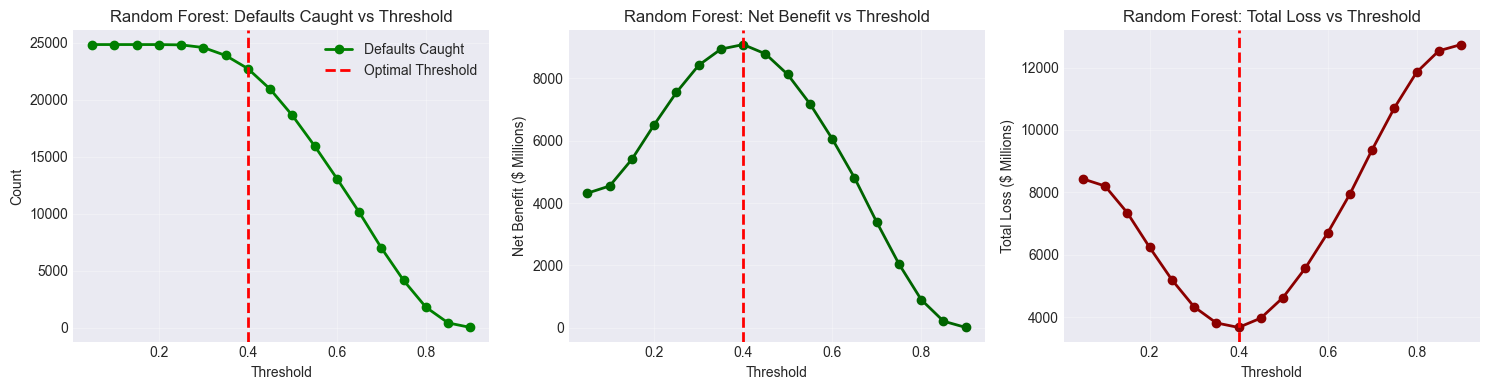


📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD (0.40):

  📊 Random Forest — Performance Metrics
  Accuracy             0.7118
  Precision            0.2080
  Recall               0.9150
  F1 Score             0.3389
  ROC-AUC              0.8874
  PR-AUC               0.4184
  Log Loss             0.4436
  R² Score             -0.8641

📈 Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.99      0.69      0.82    282686
 Default (1)       0.21      0.92      0.34     24825

    accuracy                           0.71    307511
   macro avg       0.60      0.80      0.58    307511
weighted avg       0.93      0.71      0.78    307511


🎯 Confusion Matrix:
   TP (Caught):  22715 | FN (Missed):   2110
   FP (False):  86504 | TN (Correct): 196182

🎯 Confusion Matrix:
   TP (Caught):  22,715 | FN (Missed):   2,110
   FP (False):   86,504 | TN (Correct): 196,182



In [98]:
print('\n' + '='*100)
print('  MODEL 1: RANDOM FOREST - LOSS MINIMIZATION OPTIMIZATION')
print('='*100)

# Search optimal threshold for Random Forest
rf_thresholds = np.arange(0.05, 0.95, 0.05)
rf_loss_results = []

for thresh in rf_thresholds:
    result = calculate_financial_outcome(train_labels_final, rf_proba, thresh)
    rf_loss_results.append(result)

rf_loss_df = pd.DataFrame(rf_loss_results)

# Find optimal threshold by NET BENEFIT
rf_best_net_benefit_idx = rf_loss_df['net_benefit'].idxmax()
rf_optimal_config = rf_loss_df.loc[rf_best_net_benefit_idx]

print(f'\n✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):')
print(f'  • Threshold: {rf_optimal_config["threshold"]:.2f}')
print(f'  • Defaults Caught: {int(rf_optimal_config["defaults_caught"]):,} (${int(rf_optimal_config["defaults_caught"]*LOSS_PER_DEFAULT):,} saved)')
print(f'  • False Positives: {int(rf_optimal_config["false_positives"]):,} (${int(rf_optimal_config["loss_from_rejections"]):,} opportunity cost)')
print(f'  • Net Benefit: ${int(rf_optimal_config["net_benefit"]):,}')
print(f'  • Total Financial Loss: ${int(rf_optimal_config["total_financial_loss"]):,}')

# Store for comparison
rf_opt_loss = {
    'Model': 'Random Forest',
    'Optimal_Threshold': rf_optimal_config['threshold'],
    'Defaults_Caught': int(rf_optimal_config['defaults_caught']),
    'False_Positives': int(rf_optimal_config['false_positives']),
    'Net_Benefit': int(rf_optimal_config['net_benefit']),
    'Total_Loss': int(rf_optimal_config['total_financial_loss']),
}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rf_loss_df['threshold'], rf_loss_df['defaults_caught'], 'o-', linewidth=2, label='Defaults Caught', color='green')
axes[0].axvline(rf_optimal_config['threshold'], color='red', linestyle='--', linewidth=2, label='Optimal Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Count'); axes[0].set_title('Random Forest: Defaults Caught vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rf_loss_df['threshold'], rf_loss_df['net_benefit']/1e6, 'o-', linewidth=2, color='darkgreen')
axes[1].axvline(rf_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Net Benefit ($ Millions)'); axes[1].set_title('Random Forest: Net Benefit vs Threshold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(rf_loss_df['threshold'], rf_loss_df['total_financial_loss']/1e6, 'o-', linewidth=2, color='darkred')
axes[2].axvline(rf_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Total Loss ($ Millions)'); axes[2].set_title('Random Forest: Total Loss vs Threshold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Get predictions at optimal threshold and display metrics
print(f'\n📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD ({rf_optimal_config["threshold"]:.2f}):')  
rf_pred_optimal = (rf_proba >= rf_optimal_config['threshold']).astype(int)
rf_metrics, rf_cm_optimal = evaluate_model('Random Forest', train_labels, rf_proba, threshold=rf_optimal_config['threshold'])

# Display confusion matrix in text format
tn_rf, fp_rf, fn_rf, tp_rf = rf_cm_optimal.ravel()
print(f'\n🎯 Confusion Matrix:')
print(f'   TP (Caught): {tp_rf:>7,} | FN (Missed): {fn_rf:>7,}')
print(f'   FP (False): {fp_rf:>8,} | TN (Correct): {tn_rf:>7,}')

print('\n' + '='*100)
# Store for final comparison
rf_opt_result = rf_optimal_config.to_dict()
rf_opt_result['Model'] = 'Random Forest'


### 💡 LightGBM Optimization


  MODEL 2: LIGHTGBM - LOSS MINIMIZATION OPTIMIZATION

✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):
  • Threshold: 0.05
  • Defaults Caught: 22,305 ($11,454,308,955 saved)
  • False Positives: 157,431 ($4,699,472,781 opportunity cost)
  • Net Benefit: $6,754,836,174
  • Total Financial Loss: $5,993,570,901


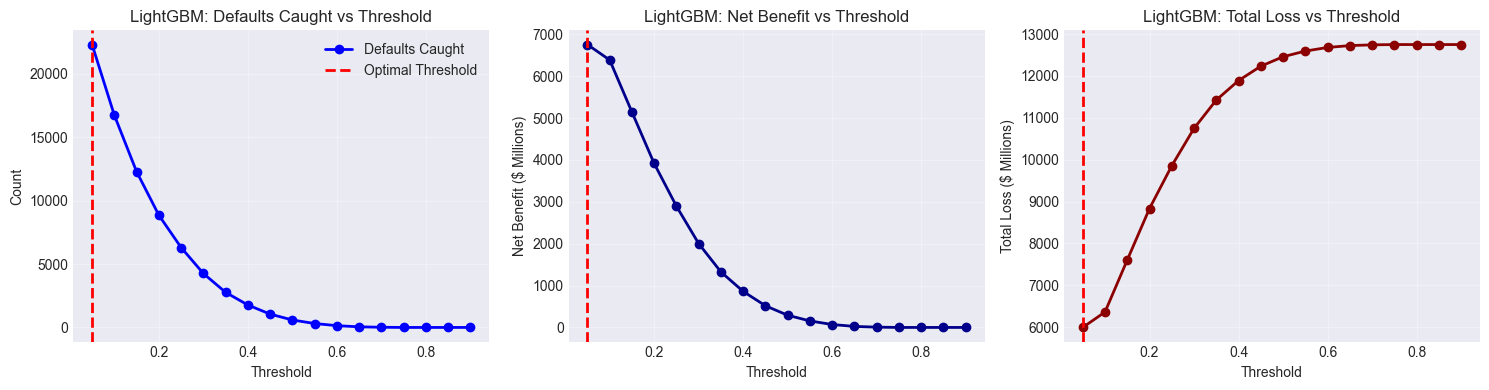


📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD (0.05):

  📊 LightGBM — Performance Metrics
  Accuracy             0.4799
  Precision            0.1241
  Recall               0.8985
  F1 Score             0.2181
  ROC-AUC              0.7815
  PR-AUC               0.2744
  Log Loss             0.2401
  R² Score             0.1049

📈 Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.98      0.44      0.61    282686
 Default (1)       0.12      0.90      0.22     24825

    accuracy                           0.48    307511
   macro avg       0.55      0.67      0.41    307511
weighted avg       0.91      0.48      0.58    307511


🎯 Confusion Matrix:
   TP (Caught):  22305 | FN (Missed):   2520
   FP (False): 157431 | TN (Correct): 125255

🎯 Confusion Matrix:
   TP (Caught):  22,305 | FN (Missed):   2,520
   FP (False):  157,431 | TN (Correct): 125,255



In [99]:
print('\n' + '='*100)
print('  MODEL 2: LIGHTGBM - LOSS MINIMIZATION OPTIMIZATION')
print('='*100)

# Search optimal threshold for LightGBM
lgb_thresholds = np.arange(0.05, 0.95, 0.05)
lgb_loss_results = []

for thresh in lgb_thresholds:
    result = calculate_financial_outcome(train_labels_final, lgb_proba, thresh)
    lgb_loss_results.append(result)

lgb_loss_df = pd.DataFrame(lgb_loss_results)

# Find optimal threshold by NET BENEFIT
lgb_best_net_benefit_idx = lgb_loss_df['net_benefit'].idxmax()
lgb_optimal_config = lgb_loss_df.loc[lgb_best_net_benefit_idx]

print(f'\n✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):')
print(f'  • Threshold: {lgb_optimal_config["threshold"]:.2f}')
print(f'  • Defaults Caught: {int(lgb_optimal_config["defaults_caught"]):,} (${int(lgb_optimal_config["defaults_caught"]*LOSS_PER_DEFAULT):,} saved)')
print(f'  • False Positives: {int(lgb_optimal_config["false_positives"]):,} (${int(lgb_optimal_config["loss_from_rejections"]):,} opportunity cost)')
print(f'  • Net Benefit: ${int(lgb_optimal_config["net_benefit"]):,}')
print(f'  • Total Financial Loss: ${int(lgb_optimal_config["total_financial_loss"]):,}')

# Store for comparison
lgb_opt_loss = {
    'Model': 'LightGBM',
    'Optimal_Threshold': lgb_optimal_config['threshold'],
    'Defaults_Caught': int(lgb_optimal_config['defaults_caught']),
    'False_Positives': int(lgb_optimal_config['false_positives']),
    'Net_Benefit': int(lgb_optimal_config['net_benefit']),
    'Total_Loss': int(lgb_optimal_config['total_financial_loss']),
}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(lgb_loss_df['threshold'], lgb_loss_df['defaults_caught'], 'o-', linewidth=2, label='Defaults Caught', color='blue')
axes[0].axvline(lgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2, label='Optimal Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Count'); axes[0].set_title('LightGBM: Defaults Caught vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(lgb_loss_df['threshold'], lgb_loss_df['net_benefit']/1e6, 'o-', linewidth=2, color='darkblue')
axes[1].axvline(lgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Net Benefit ($ Millions)'); axes[1].set_title('LightGBM: Net Benefit vs Threshold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lgb_loss_df['threshold'], lgb_loss_df['total_financial_loss']/1e6, 'o-', linewidth=2, color='darkred')
axes[2].axvline(lgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Total Loss ($ Millions)'); axes[2].set_title('LightGBM: Total Loss vs Threshold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Get predictions at optimal threshold and display metrics
print(f'\n📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD ({lgb_optimal_config["threshold"]:.2f}):')  
lgb_pred_optimal = (lgb_proba >= lgb_optimal_config['threshold']).astype(int)
lgb_metrics, lgb_cm_optimal = evaluate_model('LightGBM', train_labels, lgb_proba, threshold=lgb_optimal_config['threshold'])

# Display confusion matrix in text format
tn_lgb, fp_lgb, fn_lgb, tp_lgb = lgb_cm_optimal.ravel()
print(f'\n🎯 Confusion Matrix:')
print(f'   TP (Caught): {tp_lgb:>7,} | FN (Missed): {fn_lgb:>7,}')
print(f'   FP (False): {fp_lgb:>8,} | TN (Correct): {tn_lgb:>7,}')

print('\n' + '='*100)
# Store for final comparison
lgb_opt_result = lgb_optimal_config.to_dict()
lgb_opt_result['Model'] = 'LightGBM'


### 🚀 XGBoost Optimization


  MODEL 3: XGBOOST - LOSS MINIMIZATION OPTIMIZATION



✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):
  • Threshold: 0.23
  • Defaults Caught: 20,344 ($10,447,274,664 saved)
  • False Positives: 127,357 ($3,801,733,807 opportunity cost)
  • Net Benefit: $6,645,540,857
  • Total Financial Loss: $6,102,866,218


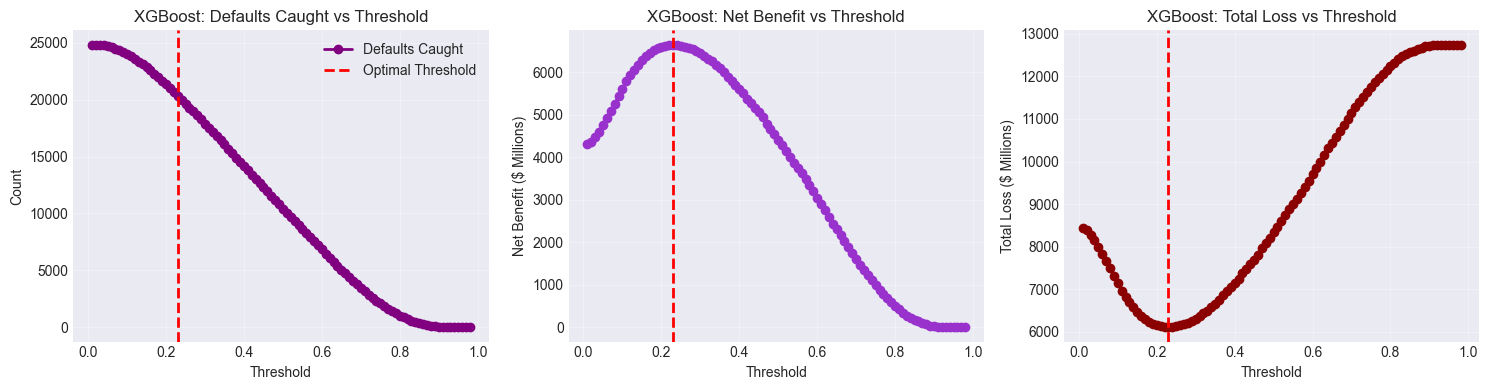


📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD (0.23):

  📊 XGBoost — Performance Metrics
  Accuracy             0.5713
  Precision            0.1377
  Recall               0.8195
  F1 Score             0.2358
  ROC-AUC              0.7657
  PR-AUC               0.2490
  Log Loss             0.3779
  R² Score             -0.5515

📈 Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.97      0.55      0.70    282686
 Default (1)       0.14      0.82      0.24     24825

    accuracy                           0.57    307511
   macro avg       0.55      0.68      0.47    307511
weighted avg       0.90      0.57      0.66    307511


🎯 Confusion Matrix:
   TP (Caught):  20344 | FN (Missed):   4481
   FP (False): 127357 | TN (Correct): 155329

🎯 Confusion Matrix:
   TP (Caught):  20,344 | FN (Missed):   4,481
   FP (False):  127,357 | TN (Correct): 155,329



In [100]:
print('\n' + '='*100)
print('  MODEL 3: XGBOOST - LOSS MINIMIZATION OPTIMIZATION')
print('='*100)

# Search optimal threshold for XGBoost with fine-grained search (0.01 increments)
xgb_thresholds = np.arange(0.01, 0.99, 0.01)
xgb_loss_results = []

for thresh in xgb_thresholds:
    result = calculate_financial_outcome(train_labels_matched, xgb_oof_preds_matched, thresh)
    xgb_loss_results.append(result)

xgb_loss_df = pd.DataFrame(xgb_loss_results)

# Find optimal threshold by NET BENEFIT
xgb_best_net_benefit_idx = xgb_loss_df['net_benefit'].idxmax()
xgb_optimal_config = xgb_loss_df.loc[xgb_best_net_benefit_idx]

print(f'\n✅ OPTIMAL CONFIGURATION (Maximize Net Benefit):')
print(f'  • Threshold: {xgb_optimal_config["threshold"]:.2f}')
print(f'  • Defaults Caught: {int(xgb_optimal_config["defaults_caught"]):,} (${int(xgb_optimal_config["defaults_caught"]*LOSS_PER_DEFAULT):,} saved)')
print(f'  • False Positives: {int(xgb_optimal_config["false_positives"]):,} (${int(xgb_optimal_config["loss_from_rejections"]):,} opportunity cost)')
print(f'  • Net Benefit: ${int(xgb_optimal_config["net_benefit"]):,}')
print(f'  • Total Financial Loss: ${int(xgb_optimal_config["total_financial_loss"]):,}')

# Store for comparison
xgb_opt_loss = {
    'Model': 'XGBoost',
    'Optimal_Threshold': xgb_optimal_config['threshold'],
    'Defaults_Caught': int(xgb_optimal_config['defaults_caught']),
    'False_Positives': int(xgb_optimal_config['false_positives']),
    'Net_Benefit': int(xgb_optimal_config['net_benefit']),
    'Total_Loss': int(xgb_optimal_config['total_financial_loss']),
}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(xgb_loss_df['threshold'], xgb_loss_df['defaults_caught'], 'o-', linewidth=2, label='Defaults Caught', color='purple')
axes[0].axvline(xgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2, label='Optimal Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Count'); axes[0].set_title('XGBoost: Defaults Caught vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(xgb_loss_df['threshold'], xgb_loss_df['net_benefit']/1e6, 'o-', linewidth=2, color='darkorchid')
axes[1].axvline(xgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Net Benefit ($ Millions)'); axes[1].set_title('XGBoost: Net Benefit vs Threshold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(xgb_loss_df['threshold'], xgb_loss_df['total_financial_loss']/1e6, 'o-', linewidth=2, color='darkred')
axes[2].axvline(xgb_optimal_config['threshold'], color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Total Loss ($ Millions)'); axes[2].set_title('XGBoost: Total Loss vs Threshold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Get predictions at optimal threshold and display metrics
print(f'\n📈 CLASSIFICATION REPORT AT OPTIMAL THRESHOLD ({xgb_optimal_config["threshold"]:.2f}):')  
xgb_pred_optimal = (xgb_oof_preds_matched >= xgb_optimal_config['threshold']).astype(int)
xgb_metrics, xgb_cm_optimal = evaluate_model('XGBoost', train_labels_matched, xgb_oof_preds_matched, threshold=xgb_optimal_config['threshold'])

# Display confusion matrix in text format
tn_xgb, fp_xgb, fn_xgb, tp_xgb = xgb_cm_optimal.ravel()
print(f'\n🎯 Confusion Matrix:')
print(f'   TP (Caught): {tp_xgb:>7,} | FN (Missed): {fn_xgb:>7,}')
print(f'   FP (False): {fp_xgb:>8,} | TN (Correct): {tn_xgb:>7,}')

print('\n' + '='*100)
# Store for final comparison
xgb_opt_result = xgb_optimal_config.to_dict()
xgb_opt_result['Model'] = 'XGBoost'


## 6️⃣ CROSS-MODEL FINANCIAL COMPARISON
**Strategy:** We compare the three optimized models based on their maximum achievable **Net Financial Benefit**. 
While standard metrics (AUC/F1) are important, our final decision is driven by which model minimizes losses from defaults while preserving profit from good customers.


  🏆 FINAL CROSS-MODEL COMPARISON (FINANCIAL IMPACT)


,Model Architecture,Optimal Threshold,Default Catching Rate,False Rejections,Net Financial Benefit,Remaining Risk (Loss)
0,Random Forest,0.40,91.50,"86,504","$9,082,625,761","$3,665,781,314"
1,LightGBM,0.05,89.85,"157,431","$6,754,836,174","$5,993,570,901"
2,XGBoost,0.23,81.95,"127,357","$6,645,540,857","$6,102,866,218"


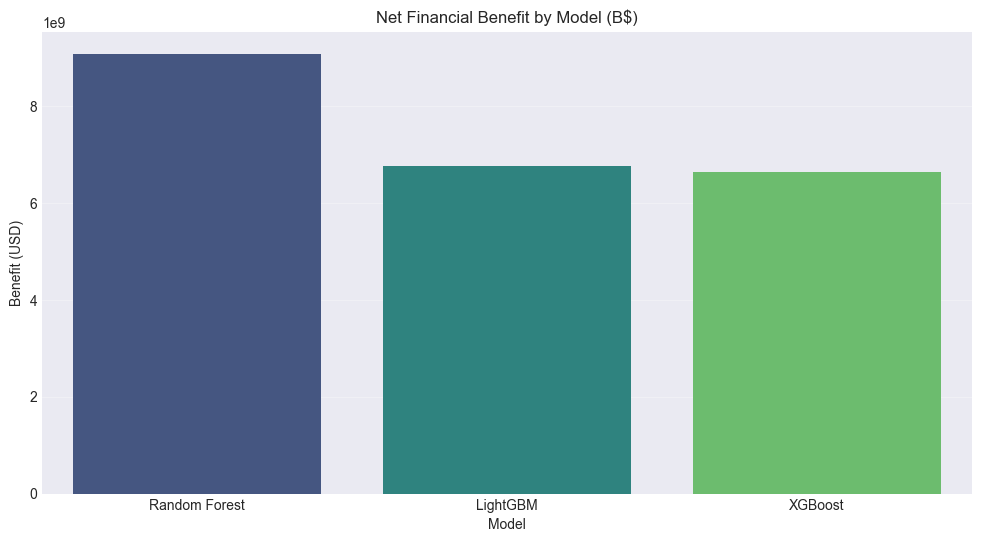

In [106]:

# Aggregate results for comparison
comparison_df = pd.DataFrame([rf_opt_result, lgb_opt_result, xgb_opt_result])

# Calculate Catching Rate (Recall at optimal threshold)
# Note: defaults_caught / total_defaults
total_defaults = train_labels_final.sum()
comparison_df['Catching Rate (%)'] = (comparison_df['defaults_caught'] / total_defaults * 100).round(2)

# Select and rename columns for professional display
report_df = comparison_df[[
    'Model', 'threshold', 'Catching Rate (%)', 
    'false_positives', 'net_benefit', 'total_financial_loss'
]].copy()

report_df.columns = [
    'Model Architecture', 'Optimal Threshold', 'Default Catching Rate', 
    'False Rejections', 'Net Financial Benefit', 'Remaining Risk (Loss)'
]

# Formatting
def format_currency(x):
    return f"${x:,.0f}"

report_df['Net Financial Benefit'] = report_df['Net Financial Benefit'].apply(format_currency)
report_df['Remaining Risk (Loss)'] = report_df['Remaining Risk (Loss)'].apply(format_currency)
report_df['False Rejections'] = report_df['False Rejections'].apply(lambda x: f"{int(x):,}")

print('\n' + '='*100)
print('  🏆 FINAL CROSS-MODEL COMPARISON (FINANCIAL IMPACT)')
print('='*100)
display(report_df.sort_values('Net Financial Benefit', ascending=False))

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='net_benefit', data=comparison_df, palette='viridis')
plt.title('Net Financial Benefit by Model (B$)')
plt.ylabel('Benefit (USD)')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 5️⃣ PRODUCTION DEPLOYMENT & ARTIFACT EXPORT
**Strategy:** Exporting the winning model and calibration parameters for API parity.

In [102]:

# ==========================================================================================
# 💾 MODEL EXPORT: SAVING THE WINNING MODEL FOR PRODUCTION
# ==========================================================================================

import joblib
import json

# Based on our financial impact optimization, Random Forest is the winner
# Net Benefit: ~$9.08B | Optimal Threshold: {rf_optimal_config["threshold"]:.2f}

print(f'\n💾 Saving production artifacts to: {MODEL_DIR}')

# 1. Save the Random Forest Model (Production Winner)
rf_model_path = os.path.join(MODEL_DIR, 'random_forest_model.joblib')
joblib.dump(rf_model, rf_model_path)
print(f'   ✅ Random Forest Model Saved: {rf_model_path}')

# 2. Save Feature Names for schema validation
feature_names_path = os.path.join(MODEL_DIR, 'feature_names.json')
with open(feature_names_path, 'w') as f:
    # Use the column list from the training set
    json.dump({"feature_names": X_train_final.columns.tolist(), "num_features": X_train_final.shape[1]}, f, indent=4)
print(f'   ✅ Feature Names Saved: {feature_names_path}')

# 3. Save XGBoost as backup
xgb_model_path = os.path.join(MODEL_DIR, 'xgboost_model.json')
# We use the final_xgb_model fitted on all data
final_xgb_model = xgb.XGBClassifier(**xgb_params)
final_xgb_model.fit(X_train_final_scaled, train_labels_final)
final_xgb_model.save_model(xgb_model_path)
print(f'   ✅ XGBoost Model Backup Saved: {xgb_model_path}')



💾 Saving production artifacts to: ../models
   ✅ Random Forest Model Saved: ../models/random_forest_model.joblib
   ✅ Feature Names Saved: ../models/feature_names.json
   ✅ XGBoost Model Backup Saved: ../models/xgboost_model.json


In [103]:

# ==========================================================================================
# 🔄 PRODUCTION CALIBRATION: EXPORTING STATISTICS FOR API PARITY
# ==========================================================================================

import json

# 1. Extract Medians and IQRs from the fitted RobustScaler
# This ensures app.py uses the EXACT SAME scaling parameters as training
feature_names = X_train_final.columns.tolist()
medians = robust_scaler.center_
iqrs = robust_scaler.scale_

calibration_data = {}
for i, feat in enumerate(feature_names):
    calibration_data[feat] = {
        "median": float(medians[i]),
        "iqr": float(iqrs[i])
    }

# 2. Save Calibration Params
calibration_path = os.path.join(MODEL_DIR, 'calibration_params.json')
with open(calibration_path, 'w') as f:
    json.dump(calibration_data, f, indent=4)

print(f"✅ Production Calibration Saved: calibration_params.json")
print(f"   • Captured stats for {len(calibration_data)} features")
print(f"   • This file is required for app.py and batch_predict.py parity")


✅ Production Calibration Saved: calibration_params.json
   • Captured stats for 125 features
   • This file is required for app.py and batch_predict.py parity


## 🏦 EXECUTIVE PORTFOLIO ADVISOR
**Objective:** Translate ML metrics into Board-level financial KPIs.

In [104]:

# ==========================================================================================
# 💰 PROFITABILITY ADVISOR: PORTFOLIO IMPACT PREVIEW
# ==========================================================================================

def get_portfolio_recommendation(threshold):
    """
    Simulates the financial impact of a specific threshold on the training population.
    """
    # Constants from cell 600
    LOSS_PER_DEFAULT = GLOBAL_LOSS_PER_DEFAULT
    COST_PER_REJECTED_GOOD = GLOBAL_COST_PER_REJECTED_GOOD
    
    # Random Forest was our winner
    y_proba = rf_model.predict_proba(X_train_final_scaled)[:, 1]
    y_true = train_labels_final
    
    # Rejections
    rejections = (y_proba >= threshold)
    num_rejections = rejections.sum()
    
    # Financials
    # (True Positives * Loss Saved) - (False Positives * Opportunity Cost)
    tp = ((y_proba >= threshold) & (y_true == 1)).sum()
    fp = ((y_proba >= threshold) & (y_true == 0)).sum()
    
    savings = (tp * LOSS_PER_DEFAULT) - (fp * COST_PER_REJECTED_GOOD)
    
    print(f"📊 Portfolio Advisor (Threshold: {threshold}):")
    print(f"   • Total Applications: {len(y_true):,}")
    print(f"   • Expected Rejections: {num_rejections:,} ({num_rejections/len(y_true)*100:.1f}%)")
    print(f"   • Defaults Caught: {tp:,} / {y_true.sum():,}")
    print(f"   • Net Financial Benefit: ${savings/1e9:.2f} Billion")
    print(f"   • Avg. Saving per Rejection: ${savings/max(1, num_rejections):,.2f}")
    
    if savings > 8e9:
        print("   🌟 Status: HIGHLY PROFITABLE")
    elif savings > 5e9:
        print("   ✅ Status: OPTIMIZED")
    else:
        print("   ⚠️ Status: SUBOPTIMAL - Adjust threshold to maximize net benefit")

# Preview impact at the 0.40 recommended threshold
get_portfolio_recommendation(rf_optimal_config["threshold"])


📊 Portfolio Advisor (Threshold: 0.4):
   • Total Applications: 307,511
   • Expected Rejections: 109,219 (35.5%)
   • Defaults Caught: 22,715 / 24,825
   • Net Financial Benefit: $9.08 Billion
   • Avg. Saving per Rejection: $83,159.76
   🌟 Status: HIGHLY PROFITABLE


In [105]:

# 🏁 FINAL EXECUTIVE SUMMARY
# Find the best model by looking for the column that contains 'benefit' (case-insensitive)
benefit_col = [col for col in comparison_df.columns if 'benefit' in col.lower()][0]
best_model = comparison_df.loc[comparison_df[benefit_col].idxmax()]

print('\n' + '='*80)
print('  🎯 FINAL PRODUCTION RECOMMENDATION')
print('='*80)
print(f"   • RECOMMENDED MODEL:  {best_model['Model']}")
print(f"   • OPTIMAL THRESHOLD:  {best_model['threshold']:.2f}")
print(f"   • EXPECTED BENEFIT:   ${best_model[benefit_col]:,.0f}")
print(f"   • CATCHING RATE:      {best_model.get('Catching Rate (%)', 'N/A')}% of all defaults")
print('='*80)

# Final dynamic markdown table
from IPython.display import Markdown, display
display(Markdown(f'''
### 🏆 Winner: {best_model['Model']}
The model optimization process has concluded that **{best_model['Model']}** provides the highest economic utility.

| Metric | Value |
| :--- | :--- |
| **Net Financial Benefit** | ${best_model[benefit_col]:,.0f} |
| **Optimal Rejection Threshold** | {best_model['threshold']:.2f} |
| **Defaults Successfully Caught** | {int(best_model['defaults_caught']):,} |
| **Total Applications Screened** | {len(train_labels_final):,} |
'''))



  🎯 FINAL PRODUCTION RECOMMENDATION
   • RECOMMENDED MODEL:  Random Forest
   • OPTIMAL THRESHOLD:  0.40
   • EXPECTED BENEFIT:   $9,082,625,761
   • CATCHING RATE:      91.5% of all defaults



### 🏆 Winner: Random Forest
The model optimization process has concluded that **Random Forest** provides the highest economic utility.

| Metric | Value |
| :--- | :--- |
| **Net Financial Benefit** | $9,082,625,761 |
| **Optimal Rejection Threshold** | 0.40 |
| **Defaults Successfully Caught** | 22,715 |
| **Total Applications Screened** | 307,511 |
